# 03. Classical Assumption Tests (Diagnostic Tests)

**Objective**: Test classical assumptions of linear regression

This notebook tests:
1. **Normality** - Are residuals normally distributed?
2. **Heteroskedasticity** - Is variance constant across observations?
3. **Autocorrelation** - Are residuals independent over time?
4. **Multicollinearity** - Are independent variables highly correlated?

**Why Important**: Violations affect:
- Coefficient estimates (bias)
- Standard errors (hypothesis tests)
- Model efficiency

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
# from pathlib import Path
import scipy.stats as stats

# Add src to path
sys.path.append('..')

from src.data.loader import DataLoader
from src.tests.test_suite import ComprehensiveTestSuite
# from src.models.panel_regression import PanelRegression
from src.utils.config import ConfigManager

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Data and Configuration

In [2]:
# Load configuration
config_manager = ConfigManager(config_dir='../config')
config = config_manager.load_config('default_config.yaml')
variables = config_manager.get_variable_info()

# Initialize loader
loader = DataLoader()
data = loader.load_json('../data/processed/audit_data.json')

# Get variable names
entity_col = variables['panel_structure']['entity_variable']
time_col = variables['panel_structure']['time_variable']
dep_var = variables['dependent_variable']['name']
indep_vars = [v['name'] for v in variables['independent_variables']]
control_vars = [v['name'] for v in variables['control_variables']]
exog_vars = indep_vars + control_vars

print(f"Data loaded: {len(data)} observations")
print(f"\nDependent variable: {dep_var}")
print(f"Independent variables: {indep_vars}")
print(f"Control variables: {control_vars}")

Loading JSON file: ..\data\processed\audit_data.json
Loaded 252 rows and 8 columns
Data loaded: 252 observations

Dependent variable: AQMS
Independent variables: ['ARL', 'FEE', 'FO']
Control variables: ['SIZE', 'ROA']


## 2. Fit Initial OLS Model

We'll use pooled OLS to get residuals for testing.
Panel-specific tests will be done in the next notebook.

In [3]:
import statsmodels.api as sm

# Prepare data for regression
y = data[dep_var]
X = data[exog_vars]

# Add constant
X = sm.add_constant(X)

# Fit pooled OLS model
pooled_model = sm.OLS(y, X).fit()
residuals = pooled_model.resid

print("\n" + "="*80)
print("POOLED OLS MODEL SUMMARY (FOR DIAGNOSTIC TESTS)")
print("="*80)
print(pooled_model.summary())

# Store residuals and fitted values
data['residuals'] = residuals
data['fitted_values'] = pooled_model.fittedvalues


POOLED OLS MODEL SUMMARY (FOR DIAGNOSTIC TESTS)
                            OLS Regression Results                            
Dep. Variable:                   AQMS   R-squared:                       0.314
Model:                            OLS   Adj. R-squared:                  0.300
Method:                 Least Squares   F-statistic:                     22.51
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           1.41e-18
Time:                        23:24:59   Log-Likelihood:                -326.24
No. Observations:                 252   AIC:                             664.5
Df Residuals:                     246   BIC:                             685.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
con

## 3. Normality Tests

**H0**: Residuals are normally distributed  
**H1**: Residuals are not normally distributed

**Tests**:
- Shapiro-Wilk (best for small/medium samples)
- Kolmogorov-Smirnov
- Jarque-Bera (based on skewness and kurtosis)


NORMALITY TESTS (Residuals)


Shapiro-Wilk Normality Test
Statistic: 0.9883
P-value: 0.0389
Reject Null Hypothesis: Yes

Interpretation: At α = 0.05, the data does NOT follow a normal distribution (p = 0.0389)

Additional Information:
  n_observations: 252
  n_missing: 0
  alpha: 0.0500


Kolmogorov-Smirnov Normality Test
Statistic: 0.0621
P-value: 0.2743
Reject Null Hypothesis: No

Interpretation: At α = 0.05, the data follows a normal distribution (p = 0.2743)

Additional Information:
  n_observations: 252
  n_missing: 0
  mean: 0.0000
  std: 0.8848
  alpha: 0.0500


Jarque-Bera Normality Test
Statistic: 3.9617
P-value: 0.1380
Reject Null Hypothesis: No

Interpretation: At α = 0.05, the data follows a normal distribution (p = 0.1380). Distribution is positively skewed (right tail) and light-tailed (platykurtic).

Additional Information:
  n_observations: 252
  n_missing: 0
  skewness: 0.1685
  kurtosis: -0.5136
  skew_interpretation: positively skewed (right tail)
  kurt_interpretat

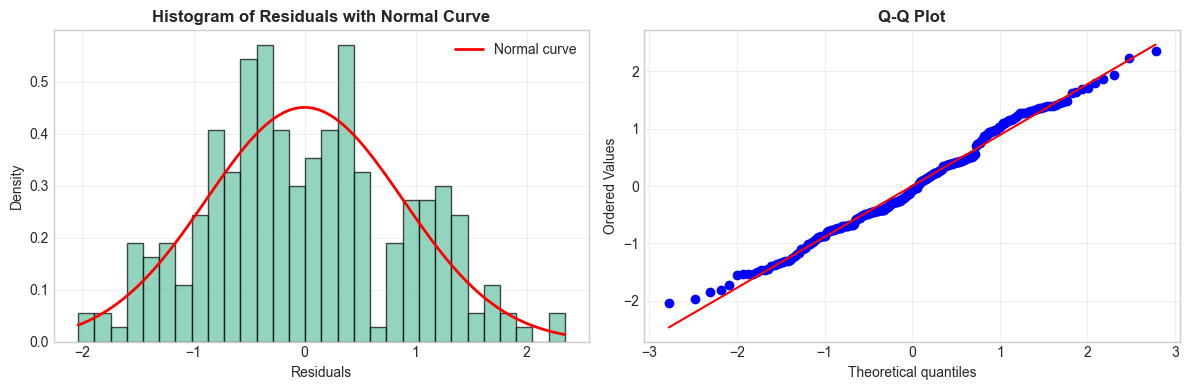


✓ Normality diagnostic plots saved to: results/normality_diagnostics.png


In [4]:
# Initialize test suite
test_suite = ComprehensiveTestSuite(alpha=config['statistical_tests']['significance_level'])

# Run normality tests
print("\n" + "="*80)
print("NORMALITY TESTS (Residuals)")
print("="*80)

# Shapiro-Wilk Test
shapiro_result = test_suite.test_normality(residuals, method='shapiro')
print("\n" + shapiro_result['formatted_output'])

# Kolmogorov-Smirnov Test
ks_result = test_suite.test_normality(residuals, method='ks')
print("\n" + ks_result['formatted_output'])

# Jarque-Bera Test
jb_result = test_suite.test_normality(residuals, method='jarque_bera')
print("\n" + jb_result['formatted_output'])

# Visual inspection
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with normal curve
axes[0].hist(residuals, bins=30, density=True, alpha=0.7, edgecolor='black')
mu, sigma = residuals.mean(), residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal curve')
axes[0].set_title('Histogram of Residuals with Normal Curve', fontweight='bold')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/normality_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Normality diagnostic plots saved to: results/normality_diagnostics.png")

## 4. Heteroskedasticity Tests

**H0**: Homoskedasticity (constant variance)  
**H1**: Heteroskedasticity (non-constant variance)

**Tests**:
- Breusch-Pagan (most common)
- White Test (more general)
- Glejser Test (specific functional forms)


HETEROSKEDASTICITY TESTS


Breusch-Pagan Test for Heteroskedasticity
Statistic: 7.6964
P-value: 0.1738
Reject Null Hypothesis: No

Interpretation: At α = 0.05, homoskedasticity holds (p = 0.1738). No evidence of heteroskedasticity.

Additional Information:
  f_statistic: 1.5500
  f_pvalue: 0.1750
  alpha: 0.0500
  test_type: LM test


White's Test for Heteroskedasticity
Statistic: 39.1352
P-value: 0.0064
Reject Null Hypothesis: Yes

Interpretation: At α = 0.05, heteroskedasticity is detected (p = 0.0064). Consider using heteroskedasticity-robust standard errors.

Additional Information:
  f_statistic: 2.1235
  f_pvalue: 0.0044
  alpha: 0.0500
  test_type: LM test


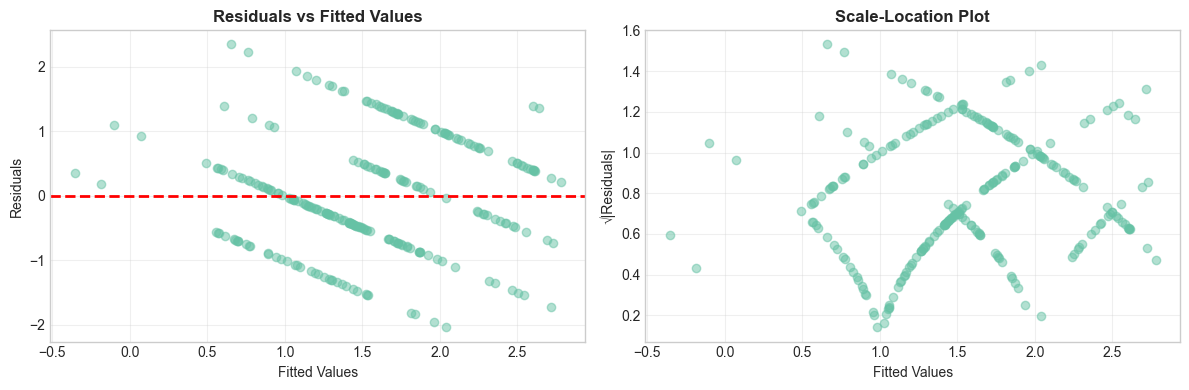


✓ Heteroskedasticity diagnostic plots saved to: results/heteroskedasticity_diagnostics.png


In [5]:
print("\n" + "="*80)
print("HETEROSKEDASTICITY TESTS")
print("="*80)

# Breusch-Pagan Test
bp_result = test_suite.test_heteroskedasticity(y, X, method='breusch_pagan')
print("\n" + bp_result['formatted_output'])

# White Test
white_result = test_suite.test_heteroskedasticity(y, X, method='white')
print("\n" + white_result['formatted_output'])

# Visual inspection: Residuals vs Fitted Values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs Fitted
axes[0].scatter(data['fitted_values'], residuals, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs Fitted Values', fontweight='bold')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].grid(True, alpha=0.3)

# Scale-Location (sqrt of absolute residuals)
axes[1].scatter(data['fitted_values'], np.sqrt(np.abs(residuals)), alpha=0.5)
axes[1].set_title('Scale-Location Plot', fontweight='bold')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('√|Residuals|')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/heteroskedasticity_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Heteroskedasticity diagnostic plots saved to: results/heteroskedasticity_diagnostics.png")

## 5. Autocorrelation Tests

**H0**: No autocorrelation (residuals are independent)  
**H1**: Autocorrelation exists

**Tests**:
- Durbin-Watson (tests for first-order autocorrelation)
- Breusch-Godfrey (more general, tests for higher orders)


AUTOCORRELATION TESTS


Durbin-Watson Test for Autocorrelation
Statistic: 0.8874
Reject Null Hypothesis: Yes

Interpretation: Positive autocorrelation detected (DW = 0.8874 < 1.5). Residuals are positively correlated over time.

Additional Information:
  acceptable_range: 1.5 - 2.5
  autocorrelation_type: positive
  ideal_value: 2.0000
  note: DW ≈ 2 indicates no autocorrelation


Breusch-Godfrey Test for Autocorrelation (lag=1)
Statistic: 78.4872
P-value: 0.0000
Reject Null Hypothesis: Yes

Interpretation: At α = 0.05, autocorrelation is detected up to lag 1 (p = 0.0000). Consider using robust standard errors clustered by entity.

Additional Information:
  f_statistic: 110.8239
  f_pvalue: 0.0000
  lags_tested: 1
  alpha: 0.0500
  test_type: LM test


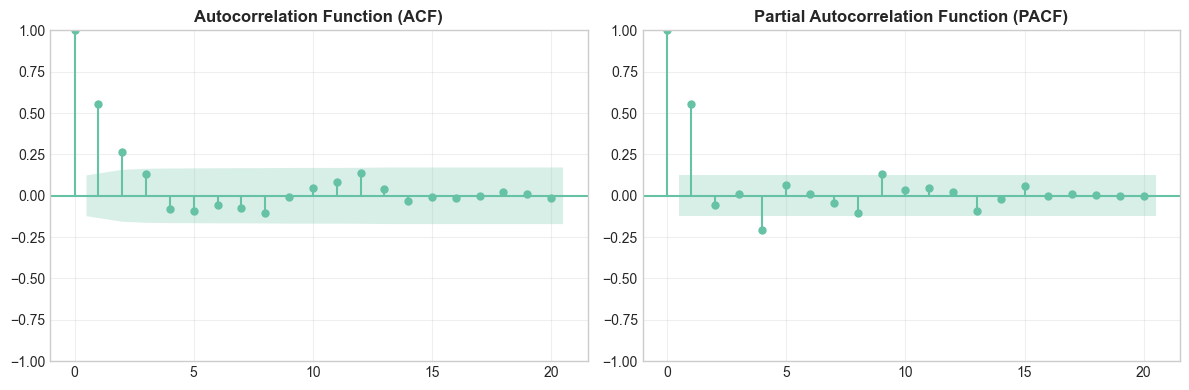


✓ Autocorrelation diagnostic plots saved to: results/autocorrelation_diagnostics.png


In [6]:
print("\n" + "="*80)
print("AUTOCORRELATION TESTS")
print("="*80)

# Durbin-Watson Test
dw_result = test_suite.test_autocorrelation(y, X, method='durbin_watson')
print("\n" + dw_result['formatted_output'])

# Breusch-Godfrey Test
bg_result = test_suite.test_autocorrelation(y, X, method='breusch_godfrey')
print("\n" + bg_result['formatted_output'])

# Visual inspection: ACF and PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ACF Plot
plot_acf(residuals, lags=20, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# PACF Plot
plot_pacf(residuals, lags=20, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/autocorrelation_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Autocorrelation diagnostic plots saved to: results/autocorrelation_diagnostics.png")

## 6. Multicollinearity Test (VIF)

**Variance Inflation Factor (VIF)**:
- VIF = 1: No correlation with other predictors
- VIF = 1-5: Moderate correlation (acceptable)
- VIF = 5-10: High correlation (problematic)
- VIF > 10: Severe multicollinearity (remove variable)

**Formula**: VIF_i = 1 / (1 - R²_i)  
where R²_i is from regressing X_i on all other predictors


MULTICOLLINEARITY TEST (VIF)

Variable    VIF Severity Status                                           Interpretation
     FEE 1.9800      Low   ✓ OK  Low multicollinearity for FEE (VIF = 1.98). Acceptable.
    SIZE 1.8300      Low   ✓ OK Low multicollinearity for SIZE (VIF = 1.83). Acceptable.
     ARL 1.1800      Low   ✓ OK  Low multicollinearity for ARL (VIF = 1.18). Acceptable.
      FO 1.0800      Low   ✓ OK   Low multicollinearity for FO (VIF = 1.08). Acceptable.
     ROA 1.0600      Low   ✓ OK  Low multicollinearity for ROA (VIF = 1.06). Acceptable.

MULTICOLLINEARITY ASSESSMENT SUMMARY

Variables tested: 5
Maximum VIF: 1.98
Mean VIF: 1.43

Severity Distribution:
  Low (VIF < 5):        5 variables
  Moderate (5 ≤ VIF < 10): 0 variables
  High (VIF ≥ 10):      0 variables

------------------------------------------------------------
OVERALL ASSESSMENT:
✓ No multicollinearity issues detected. All VIF values are acceptable.


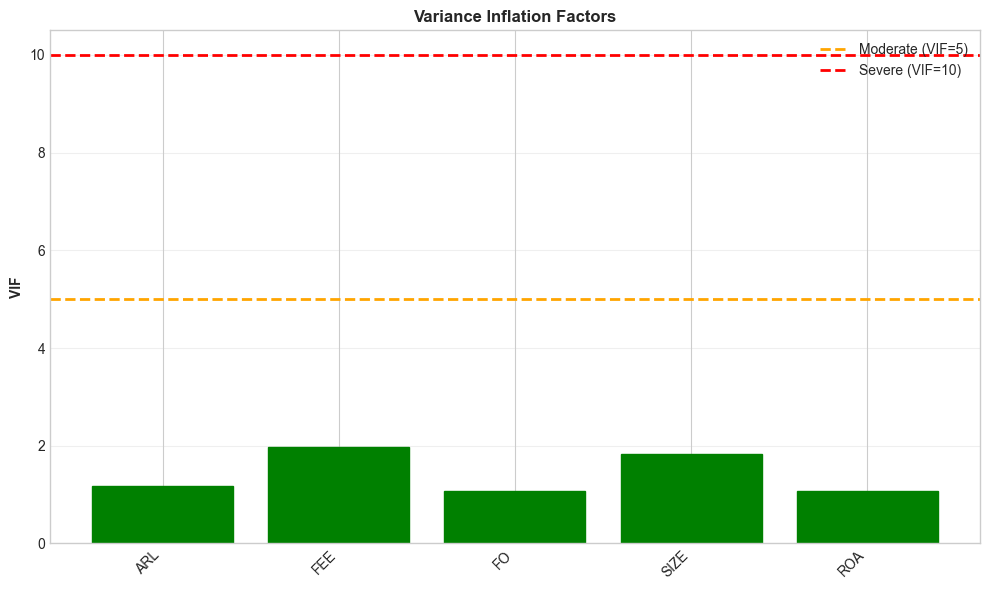


✓ VIF plot saved to: results/vif_plot.png
✓ VIF results saved to: results/vif_results.csv


In [7]:
print("\n" + "="*80)
print("MULTICOLLINEARITY TEST (VIF)")
print("="*80)

# Calculate VIF
vif_result = test_suite.test_multicollinearity(data[exog_vars], threshold=config['statistical_tests']['multicollinearity']['vif_threshold'])
print("\n" + vif_result['formatted_output'])

# Visualize VIF
vif_df = pd.DataFrame(vif_result['vif_values'])

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(vif_df)), vif_df['VIF'])

# Color bars based on VIF value
for i, bar in enumerate(bars):
    if vif_df['VIF'].iloc[i] > 10:
        bar.set_color('red')
    elif vif_df['VIF'].iloc[i] > 5:
        bar.set_color('orange')
    else:
        bar.set_color('green')

plt.axhline(y=5, color='orange', linestyle='--', linewidth=2, label='Moderate (VIF=5)')
plt.axhline(y=10, color='red', linestyle='--', linewidth=2, label='Severe (VIF=10)')
plt.xticks(range(len(vif_df)), vif_df['Variable'], rotation=45, ha='right')
plt.ylabel('VIF', fontweight='bold')
plt.title('Variance Inflation Factors', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../results/vif_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ VIF plot saved to: results/vif_plot.png")

# Save VIF results
vif_df.to_csv('../results/vif_results.csv', index=False)
print("✓ VIF results saved to: results/vif_results.csv")

## 7. Comprehensive Summary Report

Summarize all test results for thesis documentation.

In [8]:
# Create comprehensive summary
summary = {
    'Test Category': [
        'Normality (Shapiro-Wilk)',
        'Normality (Kolmogorov-Smirnov)',
        'Normality (Jarque-Bera)',
        'Heteroskedasticity (Breusch-Pagan)',
        'Heteroskedasticity (White)',
        'Autocorrelation (Durbin-Watson)',
        'Autocorrelation (Breusch-Godfrey)',
        'Multicollinearity (Max VIF)'
    ],
    'Statistic': [
        shapiro_result['result'].statistic,
        ks_result['result'].statistic,
        jb_result['result'].statistic,
        bp_result['statistic'],
        white_result['statistic'],
        dw_result['statistic'],
        bg_result['statistic'],
        vif_df['VIF'].max()
    ],
    'P-value': [
        shapiro_result['result'].p_value,
        ks_result['result'].p_value,
        jb_result['result'].p_value,
        bp_result['p_value'],
        white_result['p_value'],
        dw_result['p_value'],
        bg_result['p_value'],
        np.nan  # VIF doesn't have p-value
    ],
    'Reject H0': [
        shapiro_result['result'].reject_null,
        ks_result['result'].reject_null,
        jb_result['result'].reject_null,
        bp_result['reject_null'],
        white_result['reject_null'],
        dw_result['reject_null'],
        bg_result['reject_null'],
        vif_df['VIF'].max() > config['statistical_tests']['multicollinearity']['vif_threshold']
    ],
    'Interpretation': [
        shapiro_result['result'].interpretation,
        ks_result['result'].interpretation,
        jb_result['result'].interpretation,
        bp_result['interpretation'],
        white_result['interpretation'],
        dw_result['interpretation'],
        bg_result['interpretation'],
        'Multicollinearity detected' if vif_df['VIF'].max() > config['statistical_tests']['multicollinearity']['vif_threshold'] else 'No multicollinearity'
    ]
}

summary_df = pd.DataFrame(summary)

print("\n" + "="*80)
print("COMPREHENSIVE TEST SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv('../results/diagnostic_tests_summary.csv', index=False)
print("\n✓ Summary saved to: results/diagnostic_tests_summary.csv")


COMPREHENSIVE TEST SUMMARY
                     Test Category  Statistic  P-value  Reject H0                                                                                                                                   Interpretation
          Normality (Shapiro-Wilk)     0.9883   0.0389       True                                                                         At α = 0.05, the data does NOT follow a normal distribution (p = 0.0389)
    Normality (Kolmogorov-Smirnov)     0.0621   0.2743      False                                                                                 At α = 0.05, the data follows a normal distribution (p = 0.2743)
           Normality (Jarque-Bera)     3.9617   0.1380      False At α = 0.05, the data follows a normal distribution (p = 0.1380). Distribution is positively skewed (right tail) and light-tailed (platykurtic).
Heteroskedasticity (Breusch-Pagan)     7.6964   0.1738      False                                                             At

## 8. Remedial Measures (If Assumptions Violated)

If tests detect violations, consider these remedies:

**Heteroskedasticity**:
- Use robust standard errors (HC3, cluster-robust)
- Transform variables (log, sqrt)
- Weighted Least Squares (WLS)

**Autocorrelation**:
- Use cluster-robust standard errors
- Add time-specific effects
- Consider dynamic panel models (if needed)

**Non-normality**:
- Transform variables
- Use robust estimation
- Bootstrap standard errors

**Multicollinearity**:
- Remove highly correlated variables
- Combine correlated variables (create index)
- Use regularization (Ridge, Lasso)

In [12]:
# Recommendations based on test results
print("\n" + "="*80)
print("RECOMMENDATIONS FOR PANEL REGRESSION")
print("="*80)

recommendations = []

if bp_result['reject_null'] or white_result['reject_null']:
    recommendations.append("✓ Use robust standard errors (cluster-robust) for heteroskedasticity")

if bg_result['reject_null']:
    recommendations.append("✓ Use cluster-robust standard errors for autocorrelation")

if not shapiro_result['result'].reject_null:
    recommendations.append("✓ Normality assumption satisfied")
else:
    recommendations.append("⚠ Consider variable transformations or robust estimation")

if vif_df['VIF'].max() > config['statistical_tests']['multicollinearity']['vif_threshold']:
    high_vif_vars = vif_df[vif_df['VIF'] > config['statistical_tests']['multicollinearity']['vif_threshold']]['Variable'].tolist()
    recommendations.append(f"⚠ Review multicollinearity in: {', '.join(high_vif_vars)}")
else:
    recommendations.append("✓ No multicollinearity issues")

for rec in recommendations:
    print(rec)

print("\n" + "="*80)


RECOMMENDATIONS FOR PANEL REGRESSION
✓ Use robust standard errors (cluster-robust) for heteroskedasticity
✓ Use cluster-robust standard errors for autocorrelation
⚠ Consider variable transformations or robust estimation
✓ No multicollinearity issues



## Summary

This notebook tested all classical assumptions:
- ✓ Normality tests (Shapiro-Wilk, KS, Jarque-Bera)
- ✓ Heteroskedasticity tests (Breusch-Pagan, White)
- ✓ Autocorrelation tests (Durbin-Watson, Breusch-Godfrey)
- ✓ Multicollinearity test (VIF)
- ✓ Diagnostic visualizations
- ✓ Comprehensive summary report

**For Thesis Documentation**:
1. Report all test statistics and p-values
2. Include diagnostic plots
3. Discuss any violations and remedial measures
4. Justify use of robust standard errors if needed

**Next Steps**:
1. Run `04_panel_data_analysis.ipynb` for main regression
2. Use robust standard errors if heteroskedasticity/autocorrelation detected
3. Consider variable transformations if severe violations exist